# Encoding-Aware QSVT Resource Comparison

Polynomial degree alone is not a resource estimate. This benchmark holds one two-qubit operator and one degree sweep fixed while comparing dense embedding, FABLE, PrepSelPrep, and qubitization access models. It records normalization, query counts, logical width, and PennyLane logical-estimator gate counts.


## Truth contract

This is an encoding-aware logical resource comparison, not an executed runtime benchmark and not a fault-tolerant estimate. Generic dense encodings are costed as arbitrary unitaries; Pauli-LCU encodings use the available qubitization resource model. Application-state preparation, postselection or amplitude amplification, readout, routing, and error correction are omitted and reported in the artifact.


In [1]:
import csv

import matplotlib.pyplot as plt
import numpy as np
import pennylane as qml

from qsvt.block_encoding import matrix_block_encoding_spec, pennylane_operator_block_encoding_spec
from qsvt.notebook import benchmark_output_dirs, display_table
from qsvt.reports import save_report
from qsvt.resources import estimate_encoding_aware_resources

## Fixed operator and access models

The Hamiltonian $0.4 Z_0+0.3 Z_1+0.2 X_0$ is represented both as a finite matrix and as a Pauli sum. FABLE receives the normalization required by its entrywise compatibility condition; all normalization constants remain visible because they affect the encoded transform.


In [2]:
operator = qml.dot(
    [0.4, 0.3, 0.2],
    [qml.Z(2), qml.Z(3), qml.X(2)],
)
matrix = np.asarray(np.real_if_close(qml.matrix(operator, wire_order=[2, 3])), dtype=float)
fable_alpha = matrix.shape[0] * float(np.max(np.abs(matrix)))

specs = {
    "dense embedding": matrix_block_encoding_spec(matrix, block_encoding="embedding"),
    "FABLE": matrix_block_encoding_spec(matrix, alpha=fable_alpha, block_encoding="fable"),
    "PrepSelPrep": pennylane_operator_block_encoding_spec(
        operator, encoding_wires=[0, 1], block_encoding="prepselprep"
    ),
    "qubitization": pennylane_operator_block_encoding_spec(
        operator, encoding_wires=[0, 1], block_encoding="qubitization"
    ),
}
degrees = [1, 3, 5, 7, 9]

## Degree sweep

Each coefficient vector contains only a bounded leading monomial, so its polynomial degree is exactly the requested odd degree. The polynomial is a workload marker here; approximation quality is deliberately outside this resource-only comparison.


In [3]:
reports = {}
rows = []
for access_model, spec in specs.items():
    reports[access_model] = []
    for degree in degrees:
        coeffs = np.zeros(degree + 1)
        coeffs[-1] = 0.8
        estimate = estimate_encoding_aware_resources(spec, coeffs)
        report = estimate.as_report()
        reports[access_model].append(report)
        rows.append(
            {
                "access_model": access_model,
                "degree": degree,
                "normalization_alpha": estimate.normalization_alpha,
                "signal_operator_calls": estimate.signal_operator_calls,
                "inverse_signal_operator_calls": estimate.inverse_signal_operator_calls,
                "total_wires": estimate.total_wires,
                "total_gates": estimate.total_gates,
                "estimator_model": estimate.estimator_model,
                "estimator_available": estimate.estimator_available,
            }
        )

display_table(
    "Encoding-aware logical resources",
    rows,
    [
        ("access model", lambda row: row["access_model"]),
        ("degree", lambda row: row["degree"]),
        ("alpha", lambda row: row["normalization_alpha"]),
        ("forward calls", lambda row: row["signal_operator_calls"]),
        ("inverse calls", lambda row: row["inverse_signal_operator_calls"]),
        ("logical wires", lambda row: row["total_wires"]),
        ("logical gates", lambda row: row["total_gates"]),
        ("estimator model", lambda row: row["estimator_model"]),
    ],
    layout="rows",
)

Encoding-aware logical resources
--------------------------------
access model     degree  alpha   forward calls  inverse calls  logical wires  logical gates  estimator model                 
---------------  ------  ------  -------------  -------------  -------------  -------------  --------------------------------
dense embedding  1       0.7472  1              0              3              3236           arbitrary-unitary-block-encoding
dense embedding  3       0.7472  2              1              3              9708           arbitrary-unitary-block-encoding
dense embedding  5       0.7472  3              2              3              16180          arbitrary-unitary-block-encoding
dense embedding  7       0.7472  4              3              3              22652          arbitrary-unitary-block-encoding
dense embedding  9       0.7472  5              4              3              29124          arbitrary-unitary-block-encoding
FABLE            1       2.8     1              0   

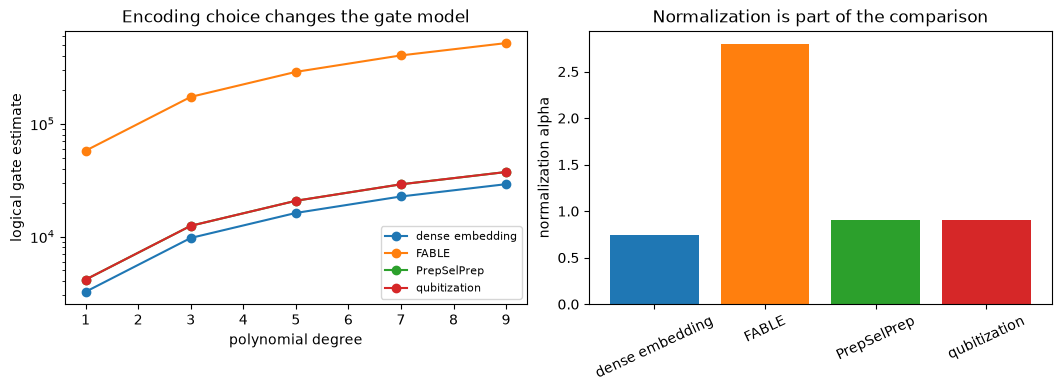

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8), constrained_layout=True)
for access_model in specs:
    model_rows = [row for row in rows if row["access_model"] == access_model]
    axes[0].plot(
        [row["degree"] for row in model_rows],
        [row["total_gates"] for row in model_rows],
        "o-",
        label=access_model,
    )
axes[0].set_yscale("log")
axes[0].set_xlabel("polynomial degree")
axes[0].set_ylabel("logical gate estimate")
axes[0].set_title("Encoding choice changes the gate model")
axes[0].legend(fontsize=8)

alphas = [specs[name].alpha for name in specs]
axes[1].bar(list(specs), alphas, color=["tab:blue", "tab:orange", "tab:green", "tab:red"])
axes[1].set_ylabel("normalization alpha")
axes[1].set_title("Normalization is part of the comparison")
axes[1].tick_params(axis="x", rotation=25)
plt.show()

## Committed artifacts

The JSON report preserves each estimator's assumptions and omissions. The CSV is a flat comparison table suitable for plotting or release-to-release diffs.


In [5]:
repo_root, artifact_dir, table_dir = benchmark_output_dirs()
payload = {
    "mode": "encoding-aware-resource-sweep",
    "implementation_kind": "pennylane-logical-encoding-comparison",
    "operator_matrix": matrix,
    "degrees": degrees,
    "rows": rows,
    "reports": reports,
    "truth_contract": {
        "truth_status": "logical_resource_comparison",
        "is_quantum_runtime_benchmark": False,
        "is_fault_tolerant_estimate": False,
        "reported_components": [
            "block_encoding_normalization",
            "qsvt_forward_and_inverse_query_counts",
            "logical_width",
            "pennylane_logical_gate_estimate",
        ],
        "omitted_components": [
            "application_state_preparation",
            "postselection_or_amplitude_amplification",
            "application_readout_or_tomography",
            "provider_compilation_and_routing",
            "error_correction",
        ],
    },
}
json_path = save_report(payload, artifact_dir / "encoding_aware_resource_sweep.json")
csv_path = table_dir / "encoding_aware_resource_summary.csv"
with csv_path.open("w", newline="", encoding="utf-8") as file:
    writer = csv.DictWriter(file, fieldnames=list(rows[0]))
    writer.writeheader()
    writer.writerows(rows)
json_display = json_path.relative_to(repo_root) if json_path.is_relative_to(repo_root) else json_path
csv_display = csv_path.relative_to(repo_root) if csv_path.is_relative_to(repo_root) else csv_path
print(f"wrote {json_display}")
print(f"wrote {csv_display}")

wrote results/benchmarks/encoding_aware_resource_sweep.json
wrote results/tables/encoding_aware_resource_summary.csv


## Validation

These checks protect the benchmark's fixed workload, estimator coverage, monotonic degree trend, and FABLE normalization condition.


In [6]:
assert len(rows) == len(specs) * len(degrees)
assert all(row["estimator_available"] for row in rows)
assert all(row["total_gates"] is not None and row["total_gates"] > 0 for row in rows)
assert specs["FABLE"].metadata["fable_compatible"]
for access_model in specs:
    gate_counts = [row["total_gates"] for row in rows if row["access_model"] == access_model]
    assert gate_counts == sorted(gate_counts)
assert json_path.exists() and csv_path.exists()
print("validation: passed")

validation: passed
